<a href="https://colab.research.google.com/github/masonsears/-Data-Processing-Visualization-CPSMA-4313-01-projects/blob/Projects/Exam2MasonSears.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Exam 2
Mason Sears
CPSMA-4313-01

In [1]:
!pip install pandas
!pip install requests
!pip install beautifulsoup4
!pip install matplotlib
!pip install seaborn

In [2]:
import pandas as pd
import requests
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import seaborn as sns
import io

PART 1

a.

In [3]:
headers = {'User-Agent': 'Chrome'}
r = requests.get('https://en.wikipedia.org/wiki/List_of_mountains_by_elevation', headers=headers)
html_contents = r.text
html_soup = BeautifulSoup(html_contents,"lxml")

In [4]:
tables = pd.read_html(io.StringIO(html_contents))
df = tables[0]
display(df.head())

,Mountain,Metres,Feet,Range,Location and notes
0,Mount Everest,8848,29029,Himalayas,Nepal/China
1,K2,8611,28251,Karakoram,Pakistan/China
2,Kangchenjunga,8586,28169,Himalayas,Nepal/India
3,Lhotse,8516,27940,Himalayas,Nepal – Climbers ascend Lhotse Face in climbin...
4,Makalu,8485,27838,Himalayas,Nepal


Displaying a table to check that the data was saved to pandas properly

b.

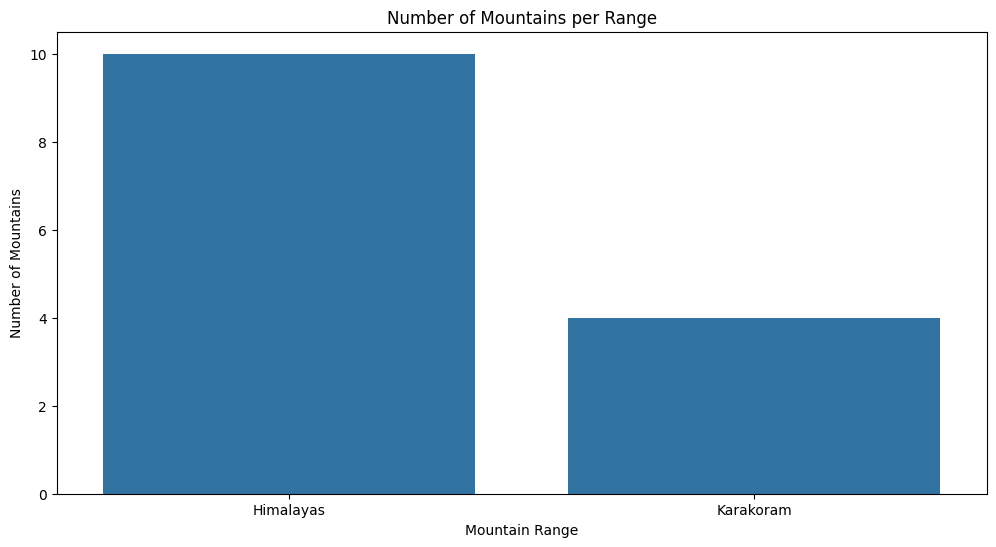

In [5]:
range_counts = df['Range'].value_counts().reset_index()
range_counts.columns = ['Range', 'Count']

plt.figure(figsize=(12, 6))
sns.barplot(x='Range', y='Count', data=range_counts,)
plt.title('Number of Mountains per Range')
plt.xlabel('Mountain Range')
plt.ylabel('Number of Mountains')

plt.show()

Bar chart showing the number of himalayan peaks and karakoram peaks.

c.

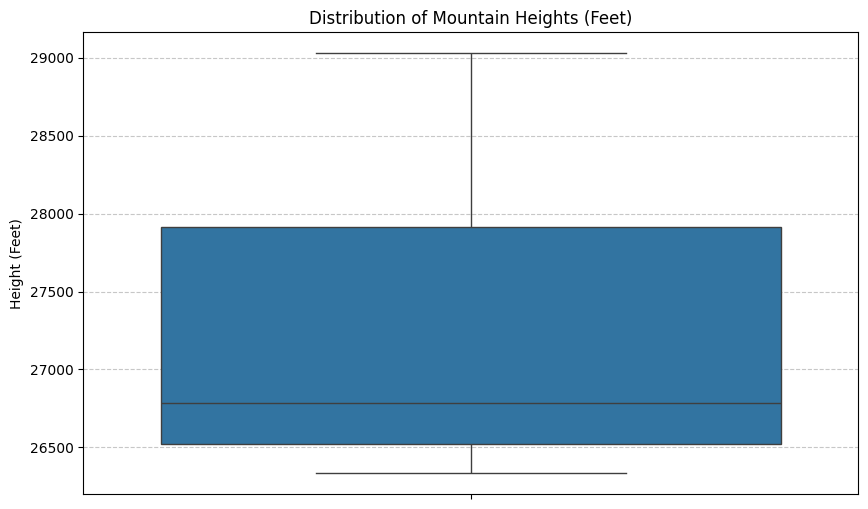

In [6]:
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['Feet'])
plt.title('Distribution of Mountain Heights (Feet)')
plt.ylabel('Height (Feet)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Boxplot is clustered between the first quarter and the thir

d. Report on mountain heights

*   Mean The averahe height is 27178.07 feet
*   The standard deviation is 879.43 feet
*   Five number summary Q1: 26335 feet Q2: 26788 feet Q3: 27914.5 feet Q4: 29029 feet

In [7]:
height_stats_feet = df['Feet'].describe()
display(height_stats_feet)

,Feet
count,14.000000
mean,27178.071429
std,879.431063
min,26335.000000
25%,26518.750000
50%,26788.000000
75%,27914.500000
max,29029.000000


e.

*   Himalayas mean 27295.6 median 26829.5
*   Karakoram mean 26884.25 median 26462

In [8]:
range_stats_feet = df.groupby('Range')['Feet'].agg(['mean', 'median'])
display(range_stats_feet)

,mean,median
Range,,
Himalayas,27295.60,26829.5
Karakoram,26884.25,26462.0


PART 2

In [9]:
%load_ext bigquery_magics

In [10]:
from google.cloud import storage
client = storage.Client('project-cc492766-18ca-4dc5-8e7')

In [12]:
%%bigquery --project project-cc492766-18ca-4dc5-8e7
SELECT
COUNT(*) as total_rows
FROM `bigquery-public-data.chicago_taxi_trips.taxi_trips`

Query is running:   0%|          |

Downloading:   0%|          |

,total_rows
0,211655459


total rows: 211655459

In [13]:
%%bigquery --project project-cc492766-18ca-4dc5-8e7
SELECT
    payment_type,
    AVG(trip_miles) as average_trip_miles
FROM
    `bigquery-public-data.chicago_taxi_trips.taxi_trips`
GROUP BY
    payment_type
ORDER BY
    average_trip_miles DESC

Query is running:   0%|          |

Downloading:   0%|          |

,payment_type,average_trip_miles
0,Prcard,7.545511
1,Prepaid,7.541555
2,Split,4.388640
3,Credit Card,4.364340
4,Unknown,4.096302
5,Mobile,4.048919
6,Way2ride,3.747887
7,Dispute,3.289322
8,Cash,2.765573
9,Pcard,2.443684


The most miles is with Prcrard which might be a debit card? and the least miles on average is No charge which may be customers not paying so the driver kicks them out.

c.

In [14]:
%%bigquery --project project-cc492766-18ca-4dc5-8e7
WITH AvgFare AS (
    SELECT AVG(fare) as average_fare
    FROM `bigquery-public-data.chicago_taxi_trips.taxi_trips`
    WHERE fare > 0
)
SELECT
    COUNT(*) as fares_above_average
FROM
    `bigquery-public-data.chicago_taxi_trips.taxi_trips` AS tt,
    AvgFare
WHERE
    tt.fare > AvgFare.average_fare
    AND tt.fare > 0

Query is running:   0%|          |

Downloading:   0%|          |

,fares_above_average
0,55515843


55515843 fares above the average

PART 3

a. It took me 2 hours and 15 minutes to complete

b. the hardest topic was the sql coding in part 2.c. I also struggled getting big query to work in the jupyter notebook.

c. I enjoyed using the HTML data gathering method as it gives me a larger range of datesets to pull from

PART 4

a. I used gemini to help my authentication errors during the sql portion. I also used gemini to help with part2.c to correct some portions of my code. Lastly, i used gemini to run the descibe command on parts 1.d and 1.e.

b. i accepted all of the responses, however i needed to correct some mistakes for part 2.c and the describe commands were in meters instead of feet like i wanted, so i needed to change the code myself for that.

c. I used my own github to create the html code

d. I attest that the resources above were the only ones utilized in completing
the exam and the work included is my own and no one else from the course.